In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules
import os
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs
ngs.SetNumThreads(8)

In [2]:
import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=10, delta_phi_deg=135, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

In [3]:
# %%capture
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 9.02e-03m,    Lx_tot: 5.90e-02m
Lx_wg = 0.00e+00m
Lz_antenna: 0.00e+00m, Lz_wall: 0.00e+00m
Lz_plasma: 1.22e-01m, Lz_pml: 4.05e-02m, Lz_tot: 2.03e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺ (edge): 8.98+0.00j, n_⟂⁺ (core): 8.98
λ_⟂⁺ (core): 9.02e-03m 
n_⟂-:0.00+1.63j, λ_⟂⁻: 4.98e-02m
==== 
Lz_wall: 0.00e+00m 
Lz_source: 1.22e-01m
[MESH GENERATED !]
Lx_wg: 0.00e+00m, wg_medium: VACUUM
Waveguide medium is not PLASMA, wg_is_plasma set to 0.0
==== 
#DoFs = 530986
==== 
w_size_R: 1.3531e-02m,    w_size_T: 6.0769e-02m
Gamma_R (SWR) = 7.774e-01
Gamma_T (SWR) = 8.025e-01

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): 6.9431e-02 W/m
Net Power Exiting to PMLs:    6.9471e-02 W/m
Plasma Bulk Conservation Error: 5.85e-02 %


In [17]:
# solver.plot_radial_density_profile()

In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260708_151928
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260708_151928


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.122, Lz_wall: 0.000, Lz_pml: 0.041, Lz_tot: 0.203
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 8.98e+00+0.00e+00j, n_perp_m: 0.00e+00+1.63e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260708_151928/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 9.02e-03
 Lx_tot: 5.90e-02
 Lz_plasma: 1.22e-01
 Lz_pml: 4.05e-02
 Lz_tot: 2.03e-01
 P_in_net: 6.94e-02
 P_out_Radial: 3.90e-07
 P_out_Toroidal: 6.95e-02
 eta_pred_R: 1.52e-02
 eta_pred_T: 1.52e-02
 eta_sim_R: 7.77e-01
 eta_sim_T: 8.03e-01
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-696.5228085516777+0j)
 lambda_perp_real: 9.02e-03
 n_para_imag: 0.00e+00
 n_para_real: 2.00e+00
 peak_z_R: 1.20e-01
 power_error_plasma: 5.85e-04
 window_size_radial: 1.35e-02
 x_target_R: 4.75e-02
--- 2D Map saved to

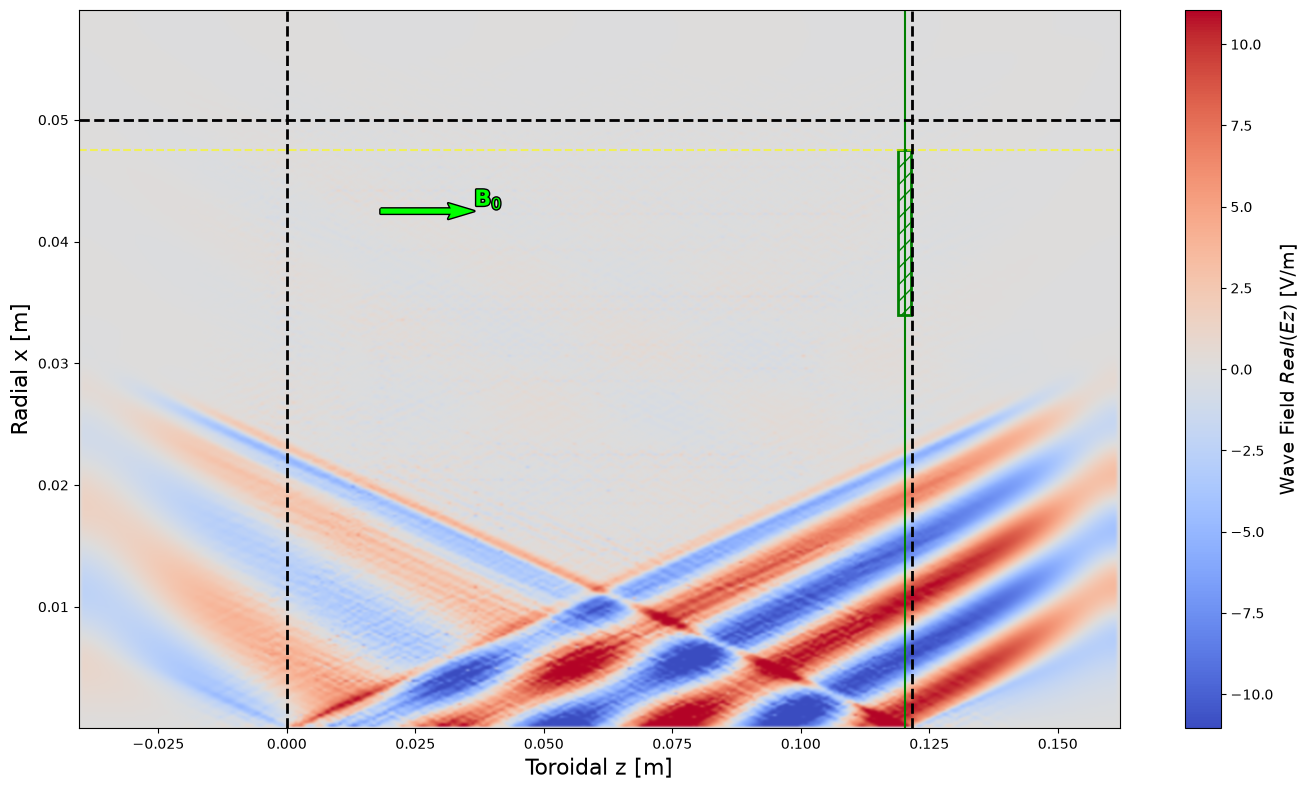

In [9]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='Ez', value_type='real',
                        antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=True, Poynting_box=False)

In [16]:
# pp_plot.plot_1D_radial_slice_with_theory(
#     h5_filepath=E_map2D_h5_filepath, 
#     cfg=cfg.__dict__, 
#     component='Ez', 
#     z_eval=0.20)  # None for exact center

In [ ]:
# Test n_para spectrum
# n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.01)


In [19]:
import sweep_param_functions as spf

# db_filepath = spf.generate_1D_radial_pml_database(cfg.__dict__, geom_mode, box_medium,save_dir="Simulation_Results")

ModuleNotFoundError: No module named 'sweep_param_functions'

In [ ]:
import sweep_param_functions as spf
# db_filepath
# Vide Radial 1D 40 pts: Simulation_Results/PML_1D_VACUUM_40pts.h5
# PLASMA Radial 1D n_para = 2, 5 avec 40pts: Simulation_Results/1D_PLASMA_40pts.h5
# PLASMA radial 1D n_para = 20, 50 avec 20pts: Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5
# PLASMA radial 1D n_para = 3 avec 20pts: Simulation_Results/1D_PLASMA_n_para=3_Lx_pml=2_to_4_5_20pts.h5
# PLASMA radial 1D n_para=2.5 to 3.5 20pts: 1D_PLASMA_n_para=2_5_to_3_5__Lx_pml=2_to4_5_20pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5
# Simulation_Results/1D_PLASMA_n_para=2_3_5_40pts.h5
# Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5

# Simulation_Results/PML_Radial_1D_Database_20260630_175333.h5 (A RE-TRAVAILLER)

# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5
# Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2


# Simulation_Results/1D_VACUUM_n_para=0_40pts.h5

# spf.plot_sweeps_all_npara("Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5")

In [ ]:
import sweep_param_functions as spf
main_files = ["Simulation_Results/1D_PLASMA_40pts.h5", 
        "Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5"]
inset_files = ["Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5"]    
params_to_plot = ['Sx_r', 'Sx_im', 'px', 'Lx_pml_ratio']
    
# spf.plot_publication_gamma_with_inset(main_files, inset_files, params_to_plot)

--- Generating Publication Figures with Multi-Curve Insets ---
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/sweep_param_functions.py:894: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_inset.legend(bbox_to_anchor=(.4, .3), fontsize=8, ncol=2, framealpha=0.9)


  -> Figure saved: Publication_GammaR_vs_Sx_r_with_Multi_Inset.svg
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/PML_Radial_1D_Database_20260703_092942.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
  -> Figure saved: Publication_GammaR_vs_Sx_im_with_Multi_Inset.svg
[!] Warning reading Simulation_Results/1D_PLASMA_40pts.h5: [Errno 2] Unable to synchronously open file (unable to open file: name = 'Simulation_Results/1D_PLASMA_40pts.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)
[!] Warning reading Simulation_Results/PML_Radial_1D_Databas

In [ ]:
# import sweep_param_functions as spf
# dataset_files = ["Simulation_Results/1D_VACUUM_n_para=0_40pts.h5", "Simulation_Results/1D_PLASMA_40pts.h5",
#                  "Simulation_Results/1D_PLASMA_n_para_20_et_50_20pts.h5"]

#     # 1. Check Mesh Stability
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['ppw_medium'])
    
#     # 2. Prove Global Independence across the Spectrum
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['n_para'])
    
#     # 3. Prove PML parameter decoupling
# spf.plot_aggregated_thermodynamics(dataset_files, target_params=['Sx_im', 'px', 'Lx_pml_ratio'])

In [ ]:
# spf.plot_vacuum_pml_validation("Simulation_Results/1D_VACCUM_n_para=0_40pts.h5")

In [ ]:
file_list = ["Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_10_to_60.h5", 
"Simulation_Results/1D_PLASMA_n_para=2_ppw_medium_pml_1_18.h5", "Simulation_Results/1D_PLASMA_n_para=2_ppw_6_to_20_40pts.h5"]

# file_list = ["Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-10_-2__2_10.h5", 
#              "Simulation_Results/1D_PLASMA_gamma_R_vs_n_para_-2_-1_25_and_1_25_2.h5"]
import sweep_param_functions as spf
# spf.plot_concatenated_general_sweeps(file_list)

In [ ]:
# %%capture
# import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.df_doe, problem_dict = sob_sur.generate_sobol_doe(N_base=256)
# print("\nFirst 5 rows of the Physical DoE:")
# print(sob_sur.df_doe.head())

In [12]:
# %%capture
# import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.run_phase2_batch_multiprocess("DoE_Sobol_PML_6D.csv", max_workers=8)

In [13]:
# import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.train_surrogate_models("DoE_Sobol_PML_6D.csv")

In [14]:
# import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.compute_sobol_indices()

In [15]:
# import PLASMA_1D_Sobol_Surrogate as sob_sur
# sob_sur.robust_pml_optimization(max_allowed_dofs=15000)

In [ ]:
# import numpy as np
# import copy
# import matplotlib.pyplot as plt
# import joblib

# # Import your actual FEM solver
# from config_dict import cfg as base_cfg 
# from solver_2DHcurl_1DH1 import LHCouplingSolver_2DHcurl_1DH1

# def final_validation_sweep(opt_params, ne_test=3e18):
#     """
#     Validates the Phase 5 optimal parameters by running the real NGSolve FEM 
#     across the entire n_parallel spectrum and comparing it to the Surrogate model.
#     """
#     print("--- Phase 6: Final Ground-Truth Validation ---")
    
#     # 1. Extract the optimal parameters from Phase 5
#     Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt = opt_params
#     print(f"[*] Testing Universal PML: Sx_r={Sx_r_opt:.2f}, Sx_im={Sx_im_opt:.2f}, px={px_opt:.2f}, L_ratio={Lx_ratio_opt:.2f}")
    
#     # 2. Load the trained surrogate to compare predictions
#     try:
#         gpr_gamma = joblib.load('surrogate_gamma.pkl')
#         scaler = joblib.load('feature_scaler.pkl')
#     except Exception as e:
#         print("[!] Warning: Surrogate models not found for comparison.")
#         gpr_gamma = None
        
#     # 3. Define the validation spectrum
#     n_para_sweep = np.linspace(2.0, 80.0, 20)
    
#     real_gamma_list = []
#     pred_gamma_list = []
    
#     for n_para in n_para_sweep:
#         print(f"  -> Solving FEM for n_para = {n_para:.1f} ...")
        
#         # --- Real FEM Execution ---
#         scan_cfg = copy.deepcopy(base_cfg)
#         scan_cfg['PML']['Sx_r'] = Sx_r_opt
#         scan_cfg['PML']['Sx_im'] = Sx_im_opt
#         scan_cfg['PML']['px'] = px_opt
#         scan_cfg['PLASMA']['ne_constant'] = ne_test
#         scan_cfg['WAVE']['n_para'] = n_para
        
#         # Geometry scaling
#         temp_solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
#         _, n_perp_p, _ = temp_solver.compute_physics_parameters()
#         lambda_perp = scan_cfg['WAVE']['lambda0'] / np.abs(n_perp_p.real)
#         scan_cfg['DOMAIN']['Lx_pml'] = Lx_ratio_opt * lambda_perp
#         scan_cfg['DOMAIN']['Lx_tot'] = scan_cfg['DOMAIN']['Lx_plasma'] + scan_cfg['DOMAIN']['Lx_pml']
#         del temp_solver
        
#         # Solve
#         try:
#             solver = LHCouplingSolver_2DHcurl_1DH1(scan_cfg, geom_mode="1D", box_medium="PLASMA", antenna_grill=None)
#             mesh = solver.build_mesh_with_PMLs()
#             solver.build_physics_Stix_B_field()
#             _, Gamma_R, _, _ = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, "1D", "PLASMA")
#             real_gamma_list.append(Gamma_R)
#         except Exception as e:
#             print(f"     [!] FEM Failed: {e}")
#             real_gamma_list.append(np.nan)
            
#         # --- Surrogate Prediction ---
#         if gpr_gamma is not None:
#             # Build the 6D feature vector exactly as in Phase 3
#             X_test = np.array([[Sx_r_opt, Sx_im_opt, px_opt, Lx_ratio_opt, np.log10(ne_test), np.log10(n_para)]])
#             X_scaled = scaler.transform(X_test)
#             pred_log_gamma = gpr_gamma.predict(X_scaled)[0]
#             pred_gamma_list.append(10 ** pred_log_gamma)
            
#     # 4. Plot the Validation Results
#     plt.figure(figsize=(9, 6))
    
#     plt.plot(n_para_sweep, real_gamma_list, marker='o', linestyle='-', color='black', lw=2, label='True FEM Physics')
    
#     if gpr_gamma is not None:
#         plt.plot(n_para_sweep, pred_gamma_list, marker='x', linestyle='--', color='red', lw=2, label='Surrogate Prediction')
        
#     plt.yscale('log')
#     plt.xlabel(r"Parallel Refractive Index ($n_\parallel$)", fontweight='bold')
#     plt.ylabel(r"Reflection Coefficient ($\Gamma_R$)", fontweight='bold')
#     plt.title(f"Universal PML Performance Validation ($n_e = {ne_test:.1e}$)")
#     plt.grid(True, which="both", ls="--", alpha=0.6)
#     plt.legend()
    
#     plt.tight_layout()
#     plt.savefig("Phase6_Final_Validation.png", dpi=300)
#     plt.show()

# if __name__ == "__main__":
#     # Replace this array with the output from Phase 5 once your 3500-run batch finishes
#     # [Sx_r, Sx_im, px, Lx_ratio]
#     dummy_optimal_params = [1.5, 3.0, 2.5, 1.0] 
#     final_validation_sweep(dummy_optimal_params, ne_test=3e18)